#**Product: Amazon Alexa**


## **Assignment Natural Language processsing - Sentiment Analysis**

### **Customer Review Classification using Random Forest**

- Dataset consists of 3000 Amazon customer reviews, star ratings, date of review, variant and feedback of various amazon Alexa products like Alexa Echo, Echo dots.
- **The objective is to discover insights into consumer reviews and perfrom sentiment analysis on the data.** Positive or Negative review?
- Dataset: www.kaggle.com/sid321axn/amazon-alexa-reviews also provided(`amazon_alexa.tsv`)
---




### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a classification model.**



**Dataset Information:**

The dataset consists of customer reviews for Amazon Alexa products, including various features related to the product variation, customer rating, and feedback sentiment.

_Features/Columns_:
* rating: The customer rating of the product (scale of 1 to 5).
* date: The date when the review was posted.
* variation: The variation or type of Alexa product the review is for (e.g., "Charcoal Fabric", "Walnut Finish").
* verified_reviews: The actual review text written by the customer.
* feedback: The target variable indicating the sentiment of the review (1 for positive sentiment and 0 for negative sentiment).



---




In [8]:
# Amazon Alexa Customer Review Sentiment Analysis
# Objective: Classify reviews as positive or negative using Random Forest

# Amazon Alexa Customer Review Sentiment Analysis

This project applies Natural Language Processing (NLP) techniques to classify Amazon Alexa customer reviews as positive or negative. The dataset contains customer ratings, product variations, review text, and feedback sentiment labels.

In [9]:
# TODO: Import necessary libraries
# Hint: You'll need pandas, numpy, matplotlib, seaborn, and various sklearn modules


In [10]:
# Import necessary libraries for data analysis, visualization, and machine learning

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [11]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# Load the dataset from Google Drive
file_path = '/content/amazon_alexa.tsv'

df = pd.read_csv(file_path, sep='\t')

# Preview the first five rows
df.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [13]:

# TODO: Load the dataset
# Hint: Use pandas to read the CSV file from your Google Drive

## Dataset Exploration

In this section, the dataset is explored to understand its structure, size, column names, data types, and overall quality before preprocessing.

In [14]:
# Display the shape of the dataset

df.shape

(3150, 5)

In [15]:
# Display the column names

df.columns

Index(['rating', 'date', 'variation', 'verified_reviews', 'feedback'], dtype='object')

In [16]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         3150 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3150 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 123.2+ KB


In [17]:
# Display statistical summary for numerical columns

df.describe()

,rating,feedback
count,3150.000000,3150.000000
mean,4.463175,0.918413
std,1.068506,0.273778
min,1.000000,0.000000
25%,4.000000,1.000000
50%,5.000000,1.000000
75%,5.000000,1.000000
max,5.000000,1.000000


In [18]:
# Check for missing values

df.isnull().sum()

,0
rating,0
date,0
variation,0
verified_reviews,1
feedback,0


In [19]:
# Check for duplicate records

df.duplicated().sum()

np.int64(715)

### Observation

The dataset structure was successfully explored. The number of records, column names, data types, missing values, and duplicate records were examined before starting the preprocessing stage.

In [20]:

# Data Visualization and Clean Up
# TODO: Visualize the distribution of feedback
# Hint: Use seaborn's countplot function

## Data Visualization and Clean Up

In this step, the feedback column is visualized to understand the number of positive and negative customer reviews.

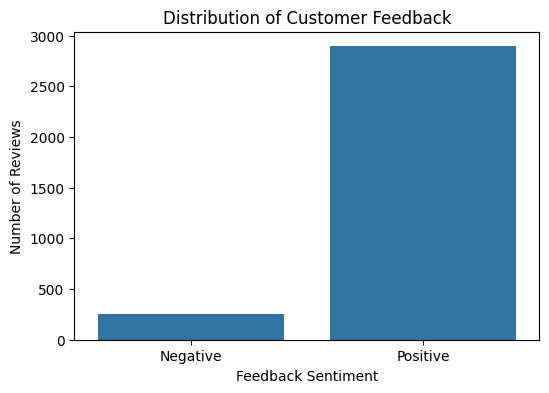

In [21]:
# Visualize the distribution of feedback using countplot

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='feedback')

plt.title('Distribution of Customer Feedback')
plt.xlabel('Feedback Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks([0, 1], ['Negative', 'Positive'])

plt.show()

### Observation

The countplot shows the distribution of customer feedback. The value 1 represents positive reviews, while the value 0 represents negative reviews.

In [22]:
# TODO: Visualize the relationship between variations and ratings
# Hint: Use seaborn's barplot function

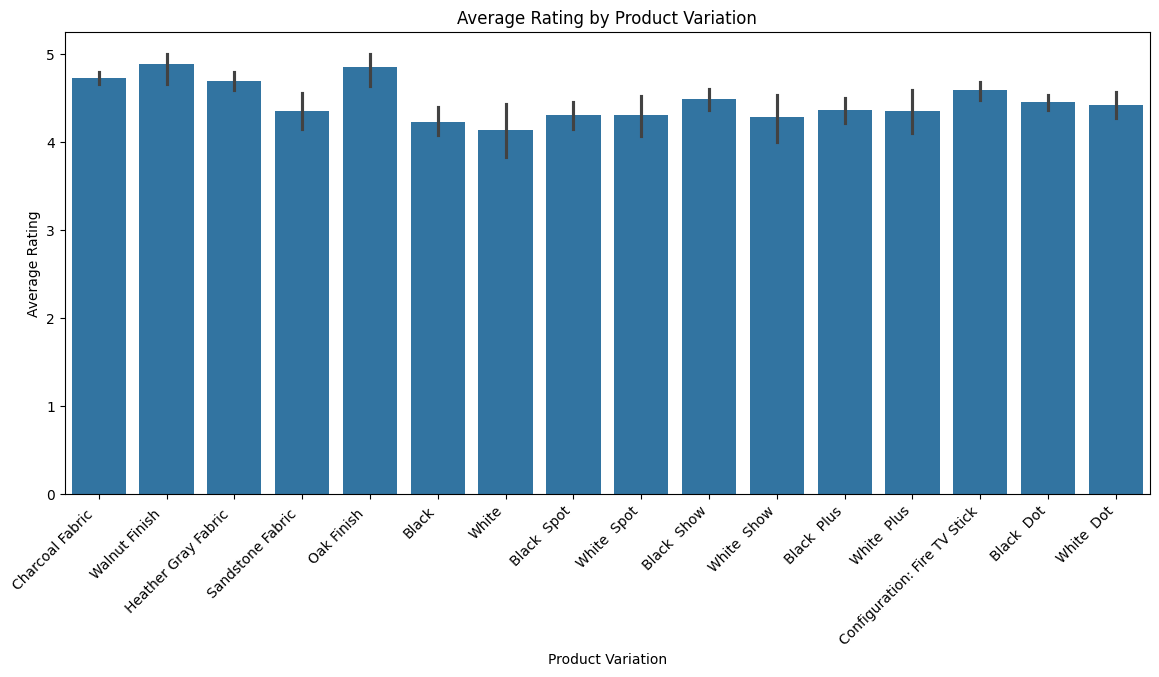

In [23]:
# Visualize the average rating for each Alexa product variation

plt.figure(figsize=(14, 6))

sns.barplot(data=df, x='variation', y='rating')

plt.title('Average Rating by Product Variation')
plt.xlabel('Product Variation')
plt.ylabel('Average Rating')

plt.xticks(rotation=45, ha='right')

plt.show()

### Observation

The bar plot shows the average rating for each Alexa product variation. Most product variations have high average ratings, which supports the earlier observation that most reviews are positive.

In [24]:
# TODO: Drop irrelevant columns
# Hint: Use the drop() method to remove 'date' and 'rating' columns

In [25]:
# Remove unnecessary columns that are not required for sentiment classification

df = df.drop(['date', 'rating'], axis=1)

# Display the updated dataframe
df.head()

,variation,verified_reviews,feedback
0,Charcoal Fabric,Love my Echo!,1
1,Charcoal Fabric,Loved it!,1
2,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,Charcoal Fabric,Music,1


### Observation

The **date** and **rating** columns were removed because they are not required for predicting customer sentiment. The remaining columns contain the product variation, review text, and feedback label, which will be used in the next preprocessing steps.

In [26]:
# One-Hot Encoding
# TODO: Perform one-hot encoding on the 'variation' column
# Hint: Use pandas get_dummies() function


In [27]:
# Perform one-hot encoding on the 'variation' column

variation_dummies = pd.get_dummies(df['variation'], prefix='variation')

# Display the encoded columns
variation_dummies.head()

,variation_Black,variation_Black Dot,variation_Black Plus,variation_Black Show,variation_Black Spot,variation_Charcoal Fabric,variation_Configuration: Fire TV Stick,variation_Heather Gray Fabric,variation_Oak Finish,variation_Sandstone Fabric,variation_Walnut Finish,variation_White,variation_White Dot,variation_White Plus,variation_White Show,variation_White Spot
0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False


### Observation

The categorical **variation** column was successfully converted into numerical features using one-hot encoding. Each product variation is now represented as a separate binary column, making it suitable for machine learning algorithms.

In [34]:
# Tokenization (Count Vectorizer)
# TODO: Tokenize the 'verified_reviews' column
# Hint: Use CountVectorizer from sklearn.feature_extraction.text

In [36]:
# Replace missing review text with an empty string before tokenization

df['verified_reviews'] = df['verified_reviews'].fillna('')

In [49]:
# Tokenize the 'verified_reviews' column using CountVectorizer

vectorizer = CountVectorizer()

review_tokens = vectorizer.fit_transform(df['verified_reviews'])

# Add prefix to avoid duplicate column names
review_tokens_df = pd.DataFrame(
    review_tokens.toarray(),
    columns=["word_" + word for word in vectorizer.get_feature_names_out()]
)

# Display the tokenized review features
review_tokens_df.head()

,word_00,word_000,word_07,word_10,word_100,word_100x,word_11,word_1100sf,word_12,word_129,...,word_youtube,word_yr,word_yrs,word_yup,word_zero,word_zigbee,word_zonked,word_zzzz,word_zzzzzzz,word_útil
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Observation

One missing value was found in the review text column and was replaced with an empty string before tokenization. This ensures that CountVectorizer can process all reviews without errors.

In [ ]:
# TODO: Combine tokenized reviews with the main dataframe
# Hint: Use pd.concat() to join the dataframes


In [50]:
# Combine one-hot encoded variation columns and tokenized review features with the main dataframe

df_model = pd.concat(
    [
        df[['feedback']],
        variation_dummies,
        review_tokens_df
    ],
    axis=1
)

# Display the final dataframe prepared for modeling
df_model.head()

,feedback,variation_Black,variation_Black Dot,variation_Black Plus,variation_Black Show,variation_Black Spot,variation_Charcoal Fabric,variation_Configuration: Fire TV Stick,variation_Heather Gray Fabric,variation_Oak Finish,...,word_youtube,word_yr,word_yrs,word_yup,word_zero,word_zigbee,word_zonked,word_zzzz,word_zzzzzzz,word_útil
0,1,False,False,False,False,False,True,False,False,False,...,0,0,0,0,0,0,0,0,0,0
1,1,False,False,False,False,False,True,False,False,False,...,0,0,0,0,0,0,0,0,0,0
2,1,False,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
3,1,False,False,False,False,False,True,False,False,False,...,0,1,0,0,0,0,0,0,0,0
4,1,False,False,False,False,False,True,False,False,False,...,0,0,0,0,0,0,0,0,0,0


### Observation

The one-hot encoded product variation features and tokenized review text features were combined into one dataframe. The dataset is now fully numerical and ready for machine learning model training.

In [ ]:
# Prepare data for modeling
# TODO: Split the data into features (X) and target (y)
# Hint: The target variable is 'feedback'


In [51]:
# Split the dataset into features (X) and target variable (y)

X = df_model.drop('feedback', axis=1)
y = df_model['feedback']

# Display the shapes of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3150, 4060)
y shape: (3150,)


### Observation

The dataset was split into features and target variable. The **X** variable contains all input features, while **y** contains the target column **feedback**, which represents positive or negative sentiment.

In [ ]:
# TODO: Split the data into training and testing sets
# Hint: Use train_test_split from sklearn.model_selection

In [52]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display the shapes of the training and testing sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2520, 4060)
X_test shape: (630, 4060)
y_train shape: (2520,)
y_test shape: (630,)


### Observation

The dataset was divided into training and testing sets. Eighty percent of the data was used to train the model, while the remaining twenty percent was reserved to evaluate the model on unseen data.

In [ ]:
# Train the Random Forest model
# TODO: Create and train the Random Forest model
# Hint: Use RandomForestClassifier from sklearn.ensemble

In [53]:
# Create and train the Random Forest classifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### Observation

A Random Forest classifier with 100 decision trees was trained using the training dataset. The model is now ready to make predictions on unseen customer reviews.

In [54]:
# Evaluate the model
# TODO: Generate predictions and create confusion matrix
# Hint: Use the predict() method and confusion_matrix from sklearn.metrics


In [55]:
# Generate predictions using the trained Random Forest model

y_pred = rf_model.predict(X_test)

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix values
print(cm)

[[ 20  38]
 [  5 567]]


### Observation

The trained Random Forest model was used to predict the sentiment of the test dataset. A confusion matrix was generated to summarize the model's prediction results before visualizing them.

In [ ]:
# TODO: Plot confusion matrix
# Hint: Use seaborn's heatmap function

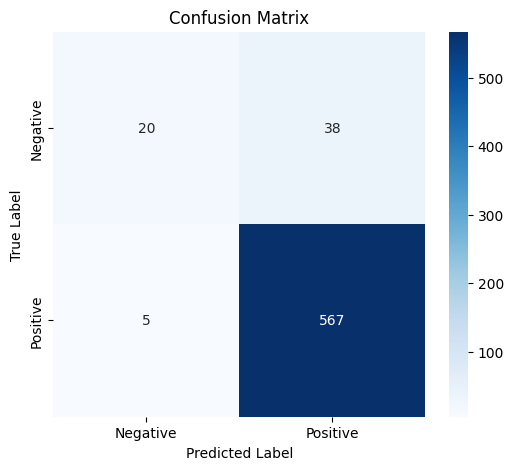

In [56]:
# Visualize the confusion matrix using a heatmap

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

### Observation

The confusion matrix heatmap provides a visual summary of the model's predictions. Most positive reviews were classified correctly, while a smaller number of negative reviews were misclassified as positive.

In [ ]:
# TODO: Print classification report
# Hint: Use classification_report from sklearn.metrics

In [57]:
# Print the classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.34      0.48        58
           1       0.94      0.99      0.96       572

    accuracy                           0.93       630
   macro avg       0.87      0.67      0.72       630
weighted avg       0.92      0.93      0.92       630



### Observation

The classification report summarizes the model's performance using precision, recall, F1-score, and accuracy. These metrics provide a more detailed evaluation than accuracy alone.

In [ ]:
# Feature Importance
# TODO: Visualize feature importance
# Hint: Access feature_importances_ attribute of the trained model

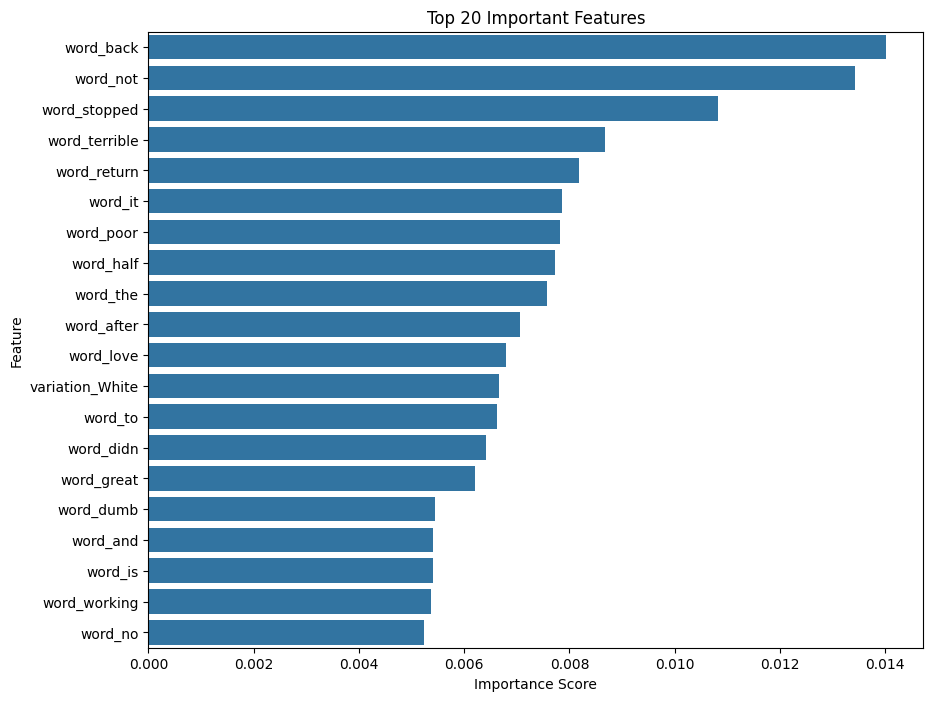

In [58]:
# Display the top 20 most important features

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 20 Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.show()

### Observation

The feature importance chart shows the variables that had the greatest influence on the Random Forest model. Features with higher importance scores contributed more to predicting customer sentiment.

In [ ]:
# TODO: Make predictions on new data
# Hint: Create a function that takes a new review text, preprocesses it,
# and uses the trained model to predict its sentiment

In [60]:
# Predict the sentiment of a new customer review

def predict_sentiment(review_text):

    # Transform the review text using the trained CountVectorizer
    review_vector = vectorizer.transform([review_text])

    review_vector_df = pd.DataFrame(
        review_vector.toarray(),
        columns=review_tokens_df.columns
    )

    # Create a dataframe for product variation
    variation_input = pd.DataFrame(
        np.zeros((1, len(variation_dummies.columns))),
        columns=variation_dummies.columns
    )

    # Combine variation and review features
    new_sample = pd.concat(
        [variation_input, review_vector_df],
        axis=1
    )

    # Ensure the column order matches the training data
    new_sample = new_sample.reindex(columns=X.columns, fill_value=0)

    # Predict sentiment
    prediction = rf_model.predict(new_sample)[0]

    if prediction == 1:
        return "Positive Review"
    else:
        return "Negative Review"

In [ ]:
# Example usage of your prediction function:
# new_review = "I love my Alexa device! It's so helpful."
# predicted_sentiment = predict_sentiment(new_review)
# print(f"The sentiment of the new review is: {predicted_sentiment}")

In [61]:
# Example usage

new_review = "I love my Alexa device! It's so helpful."

predicted_sentiment = predict_sentiment(new_review)

print("Prediction:", predicted_sentiment)

Prediction: Positive Review


### Observation

A prediction function was created to classify new customer reviews. The function applies the same preprocessing steps used during training and predicts whether the review expresses positive or negative sentiment.

## Note

Tasks 1 through 7 have already been completed in the previous sections of this notebook, including data preprocessing, visualization, feature engineering, model training, evaluation, feature importance analysis, and prediction on new reviews. Since the instructions below repeat the same implementation, they are not duplicated. The notebook therefore continues with **Task 8 (Model Performance Analysis)**, which is the remaining step to complete the assignment.

In [ ]:
# Task 1: Import Libraries and Dataset

# Hint: You need to import libraries like pandas, numpy, matplotlib, seaborn, etc.
# Don't forget to mount Google Drive and load the CSV file using pandas.
# Use `pd.read_csv()` to load the data into a pandas DataFrame.

# TODO: Import necessary libraries

# TODO: Mount Google Drive

# TODO: Load the dataset into a DataFrame and preview the first few rows.


# Hint: Use `sns.countplot()` to visualize the feedback distribution and a bar plot to compare variations and feedback.
# Drop the columns 'date' and 'rating' as they are not relevant for the analysis.

# TODO: Visualize the distribution of feedback (positive/negative)

# TODO: Visualize the relationship between product variation and feedback

# TODO: Drop irrelevant columns ('date', 'rating')



# Hint: Use `pd.get_dummies()` to create one-hot encoded columns for 'variation'.
# Then, concatenate these encoded columns back to the original DataFrame and drop the 'variation' column.

# TODO: Perform one-hot encoding on the 'variation' column




# Hint: Use `CountVectorizer` to tokenize the text data and convert it into numerical representation.
# After transforming the text, drop the 'verified_reviews' column and concatenate the numerical data with the rest of the DataFrame.

# TODO: Tokenize the 'verified_reviews' column using CountVectorizer






# Hint: Use `train_test_split()` to split the data into training and testing sets.
# You need to specify `test_size=0.2` to reserve 20% of the data for testing.

# TODO: Split the data into training and testing sets




# Hint: Initialize a `RandomForestClassifier` with 100 estimators.
# Use the `fit()` method to train the model on the training data.

# TODO: Define and train a Random Forest Classifier





# Hint: Use the `predict()` method to generate predictions for the test data.
# Use `confusion_matrix()` to create the confusion matrix and visualize it using a heatmap.
# Print out a `classification_report()` to evaluate the model's precision, recall, and F1 score.

# TODO: Generate predictions and evaluate the model's performance using a confusion matrix and classification report


## Model Performance Analysis

This section compares the model's performance on the training and testing datasets to determine whether the model is overfitting, underfitting, or generalizing well.

In [ ]:
# Task 8: Analyze Model Performance
# Hint: Use the `score()` method to calculate accuracy for both training and test sets.
# Compare the results and discuss if the model is overfitting or underfitting.

# TODO: Compare training and testing accuracy and discuss model performance


In [62]:
# Compare training and testing accuracy

train_accuracy = rf_model.score(X_train, y_train)
test_accuracy = rf_model.score(X_test, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.9964
Testing Accuracy: 0.9317


### Observation

The training accuracy was **99.64%**, while the testing accuracy was **93.17%**. The model performs well on unseen data, although the higher training accuracy suggests a slight degree of overfitting. Overall, the Random Forest model demonstrates strong predictive performance.